# Snake reinforcement learning — solved project

This notebook implements **n-step advantage actor–critic (A2C)**, trains agents for full-board and local-view observations, and compares them with a uniform random policy using raw environment rewards. The model, optimizer, sampled actions, return targets, loss, and gradient updates replace all template placeholders. Reusable implementations are in `rl_agent.py` and the two environment modules.

The original task is unusual: hitting a wall gives −0.1 without ending the episode, self-biting truncates the body and gives −0.2, eating fruit gives +0.5, and filling the board gives +1 and resets that board. These rules are retained. There is no reward shaping or action masking.

**Observation caveat:** the file named “fully observable” provides the entire occupancy grid, but not the ordered tail list used by the simulator. Its observation therefore need not uniquely identify the full internal state. The partial variant is a head-centered 5×5 crop. Both agents here are memoryless baselines; a recurrent policy could address observation aliasing.

In [1]:
import os
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL','2')
os.environ.setdefault('TF_NUM_INTEROP_THREADS','1')
os.environ.setdefault('TF_NUM_INTRAOP_THREADS','1')
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import environments_fully_observable
import environments_partially_observable
from rl_agent import A2C, set_seed, evaluate_policy
set_seed(0)
ARTIFACTS = Path('artifacts')
ARTIFACTS.mkdir(exist_ok=True)

## Environment definition

Four actions: UP=0, RIGHT=1, DOWN=2, LEFT=3. A 7×7 board includes its border, leaving a 5×5 playable area. Input channels are EMPTY, FRUIT, BODY, HEAD; walls are all-zero vectors. Each environment batch maintains independent snakes and a private random generator.

The executed configuration uses 64 boards, 16-step rollouts and 1,000 optimizer updates: **1,024,000 environment transitions per agent**. The template's unimplemented 1,000-board × 5,000-step configuration is replaced by this explicitly stated, practical A2C configuration. Change these constants to increase the budget.

Full observation shape: (64, 7, 7, 4)
Partial observation shape: (1, 5, 5, 4)


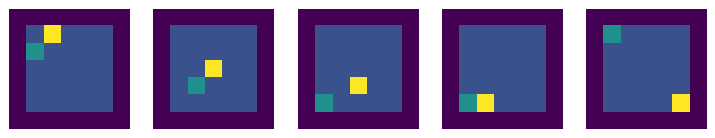

In [2]:
N_BOARDS = 64
GAMMA = .9
ITERATIONS = 1000  # optimizer updates, each containing ROLLOUT_STEPS per board
ROLLOUT_STEPS = 16

def get_env(n=N_BOARDS, seed=0, partial=False):
    if partial:
        return environments_partially_observable.OriginalSnakeEnvironment(n,7,2,seed=seed)
    return environments_fully_observable.OriginalSnakeEnvironment(n,7,seed=seed)

def full_factory(n,seed): return get_env(n,seed,partial=False)
def partial_factory(n,seed): return get_env(n,seed,partial=True)
env_ = get_env()
fig,axs = plt.subplots(1,5,figsize=(10,3))
for ax,board in zip(axs,env_.boards):
    ax.imshow(board,origin='lower',vmin=0,vmax=4,cmap='viridis')
    ax.axis('off')
plt.show()
print('Full observation shape:',env_.to_state().shape)
print('Partial observation shape:',get_env(1,partial=True).to_state().shape)

## Model and objective

A shared 128–128 ReLU network has two heads: four action logits and a scalar value. The actor samples from the softmax categorical distribution during training. No separate action-value network $Q$ is needed for A2C.

For each rollout, bootstrap the final observation with the critic and compute backwards:
$$G_t=r_t+\gamma(1-d_t)G_{t+1},\qquad G_T=V_\theta(o_T).$$
Here $d_t=1$ only when a filled board resets; wall hits and self-bites are nonterminal. Stop the bootstrap at a reset so the previous episode does not inherit the next episode's value.

$$A_t=\operatorname{stopgrad}(G_t-V_\theta(o_t)),$$
$$L_\pi=-\mathbb E[\log\pi_\theta(a_t\mid o_t)\,\widehat A_t],\quad
L_V=\tfrac12\mathbb E[(G_t-V_\theta(o_t))^2],$$
$$L=L_\pi+0.5L_V-0.01H(\pi_\theta).$$
$\widehat A$ is the batch-standardized, detached advantage. Return targets are detached too; gradient flows through the critic prediction in its own loss. Entropy encourages exploration. Global gradient norm is clipped at 0.5. All actions are sampled using the behavior policy that generated the rollout; no replay buffer is used.

In [3]:
learner = A2C(env_.to_state().shape[1:],learning_rate=7e-4,gamma=GAMMA)
agent = learner.agent  # action logits
value = learner.value # scalar critic
learner.model.summary()

Model: "snake_actor_critic"
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ observation         │ (None, 7, 7, 4)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 196)       │          0 │ observation[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     25,216 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     16,512 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ action_logits       │ (None, 4)         │     

## Training

`learner.train` collects on-policy rollouts and calls the `tf.GradientTape` loss/update implemented in `rl_agent.A2C.update`. It applies the actual optimizer gradients to shared trainable variables once per rollout. Wall/self-bite/win event rates are logged alongside loss, entropy, reward, and snake length.

In [4]:
optimizer = learner.optimizer  # current public tf.keras.optimizers.Adam API
print('Optimizer:',type(optimizer).__name__)

Optimizer: Adam


In [5]:
history_full = learner.train(env_,updates=ITERATIONS,rollout_steps=ROLLOUT_STEPS)
full_history = pd.DataFrame(history_full)
full_history.to_csv(ARTIFACTS/'training_full.csv',index=False)
learner.model.save(ARTIFACTS/'actor_critic_full.keras')
print('Full-board training complete:',int(full_history.transitions.iloc[-1]),'transitions')

Update    1/1000: reward/step=-0.0128, entropy=1.386, length=1.08
Update  100/1000: reward/step=-0.0121, entropy=1.357, length=1.06
Update  200/1000: reward/step=0.0194, entropy=0.849, length=2.06
Update  300/1000: reward/step=0.0883, entropy=0.423, length=3.00
Update  400/1000: reward/step=0.1142, entropy=0.276, length=3.23
Update  500/1000: reward/step=0.1189, entropy=0.218, length=4.16
Update  600/1000: reward/step=0.1207, entropy=0.180, length=3.48
Update  700/1000: reward/step=0.1222, entropy=0.166, length=3.39
Update  800/1000: reward/step=0.1227, entropy=0.164, length=3.48
Update  900/1000: reward/step=0.1228, entropy=0.147, length=2.92
Update 1000/1000: reward/step=0.1240, entropy=0.126, length=3.66
Full-board training complete: 1024000 transitions


## Random policy reward

A uniform random policy is a reference, not a learned agent. Evaluation runs use fresh environments and action generators, do not update weights, and report reward per environment move rather than averaging rewards across different episode lengths. Episodes can be very long because collisions are nonterminal.

In [6]:
random_full_results = evaluate_policy(full_factory,seeds=(100,101,102),n_boards=64,steps=1000)
print(pd.DataFrame(random_full_results).to_string(index=False))

 seed  transitions  mean_reward  fruit_rate  wall_rate  self_bite_rate  win_rate  mean_length
  100        64000    -0.014345    0.017281   0.197797        0.016031       0.0     1.067313
  101        64000    -0.014483    0.016813   0.198297        0.015297       0.0     1.065172
  102        64000    -0.014581    0.017812   0.202531        0.016172       0.0     1.071641


## Train the partially observable agent

The same algorithm, network widths, reward scale, update count, and discount are used for the 5×5 local view. Fruit outside the crop is invisible. The agent has no recurrence, so it cannot explicitly remember previously seen fruit or resolve all hidden-state ambiguity. This is a clearly scoped observation-based baseline, not a general solution to the POMDP.

In [7]:
set_seed(0)
partial_env = get_env(partial=True)
partial_learner = A2C(partial_env.to_state().shape[1:],learning_rate=7e-4,gamma=GAMMA)
history_partial = partial_learner.train(partial_env,updates=ITERATIONS,rollout_steps=ROLLOUT_STEPS)
partial_history = pd.DataFrame(history_partial)
partial_history.to_csv(ARTIFACTS/'training_partial.csv',index=False)
partial_learner.model.save(ARTIFACTS/'actor_critic_partial.keras')

Update    1/1000: reward/step=-0.0126, entropy=1.386, length=1.08
Update  100/1000: reward/step=-0.0042, entropy=1.174, length=1.03
Update  200/1000: reward/step=0.0027, entropy=1.129, length=1.14
Update  300/1000: reward/step=0.0590, entropy=0.427, length=3.55
Update  400/1000: reward/step=0.1093, entropy=0.222, length=5.80
Update  500/1000: reward/step=0.1137, entropy=0.170, length=5.94
Update  600/1000: reward/step=0.1147, entropy=0.135, length=6.36
Update  700/1000: reward/step=0.1155, entropy=0.119, length=5.97
Update  800/1000: reward/step=0.1174, entropy=0.110, length=6.20
Update  900/1000: reward/step=0.1177, entropy=0.108, length=6.56
Update 1000/1000: reward/step=0.1170, entropy=0.084, length=6.77


## Learning curves

Reward is the unmodified simulator reward. The rolling window is descriptive smoothing over 25 optimizer updates; it is not an additional optimization signal. Entropy lies between 0 and log(4) for the categorical policy. Reward improvement by itself does not establish that the policy reliably fills the board, so event rates are evaluated separately below.

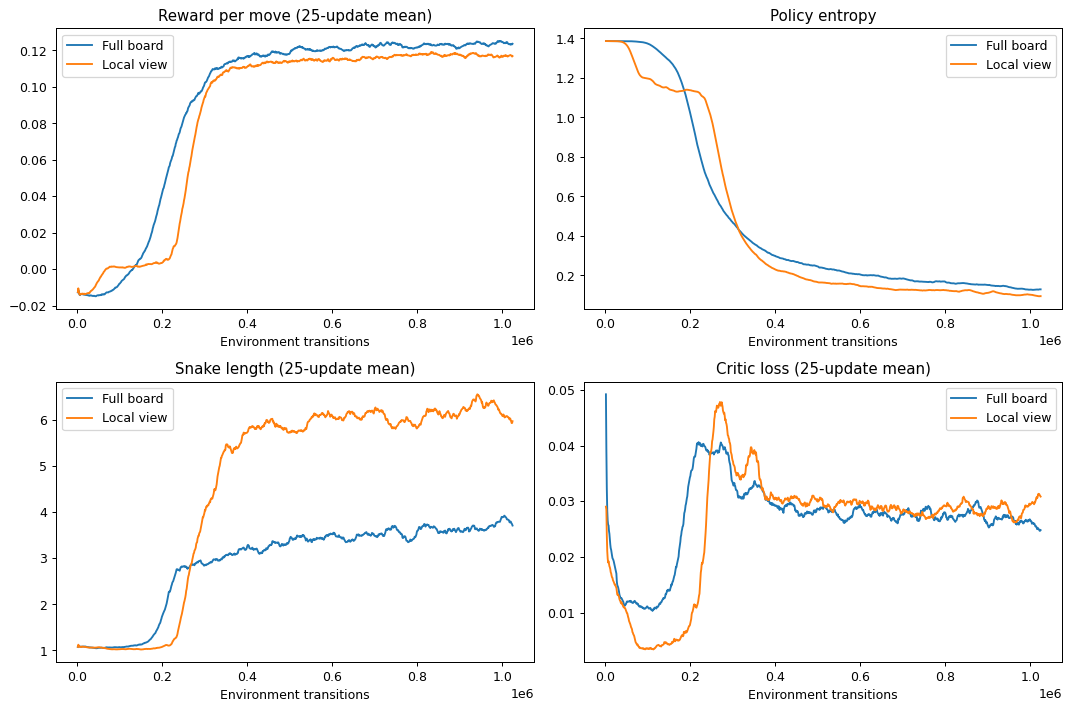

In [8]:
fig,axs = plt.subplots(2,2,figsize=(12,8))
for history,label in [(full_history,'Full board'),(partial_history,'Local view')]:
    x = history.transitions
    for ax,key,title in zip(axs.ravel(),['mean_reward','entropy','mean_length','value_loss'],
                            ['Reward per move (25-update mean)','Policy entropy','Snake length (25-update mean)','Critic loss (25-update mean)']):
        y = history[key].rolling(25,min_periods=1).mean()
        ax.plot(x,y,label=label);ax.set_title(title);ax.set_xlabel('Environment transitions');ax.legend()
plt.tight_layout()
plt.savefig(ARTIFACTS/'learning_curves.png',dpi=140)
plt.show()

## Held-out evaluation

Each row aggregates **three evaluation seeds × 64 boards × 1,000 moves**. The learned stochastic policy matches the training policy; argmax/greedy evaluation is also reported because removing sampling can change exploration and can trap a policy in loops. Random policies receive the same action set and reward rules. Training uses seed 0 for each agent; variability below is across evaluation seeds, **not independent training runs**. It must not be interpreted as a robust multi-training-seed comparison.

                            reward_mean  reward_sd  fruit_rate  wall_rate  self_bite_rate  win_rate  mean_length
observation policy                                                                                              
full        A2C greedy         0.121943   0.003344    0.279719   0.018865        0.080151  0.000000     3.921224
            A2C stochastic     0.124320   0.000279    0.282625   0.001396        0.084266  0.000000     3.750406
            random            -0.014470   0.000119    0.017302   0.199542        0.015833  0.000000     1.068042
partial     A2C greedy         0.117819   0.000296    0.258266   0.000000        0.056568  0.000000     6.105385
            A2C stochastic     0.117878   0.000180    0.258411   0.000146        0.056568  0.000000     6.024583
            random            -0.014470   0.000119    0.017302   0.199542        0.015833  0.000000     1.068042


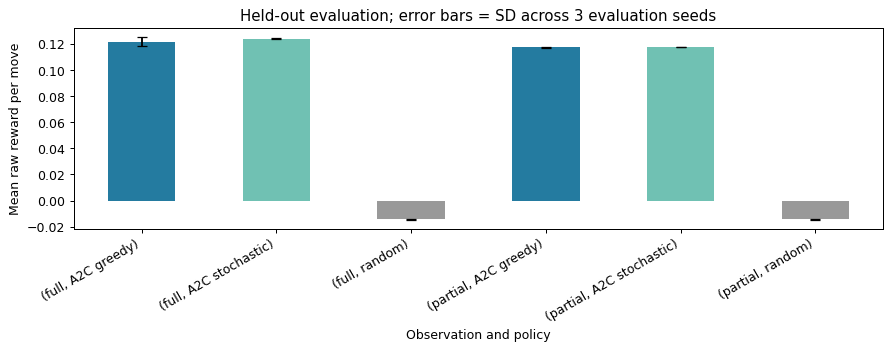

In [9]:
records = []
for r in random_full_results: records.append(dict(observation='full',policy='random',**r))
for kind,factory,model in [('full',full_factory,learner.model),('partial',partial_factory,partial_learner.model)]:
    if kind=='partial':
        for r in evaluate_policy(factory,seeds=(100,101,102),n_boards=64,steps=1000):
            records.append(dict(observation=kind,policy='random',**r))
    for greedy,label in [(False,'A2C stochastic'),(True,'A2C greedy')]:
        for r in evaluate_policy(factory,model,seeds=(100,101,102),n_boards=64,steps=1000,greedy=greedy):
            records.append(dict(observation=kind,policy=label,**r))
results = pd.DataFrame(records)
results.to_csv(ARTIFACTS/'evaluation_seeds.csv',index=False)
summary = results.groupby(['observation','policy']).agg(
    reward_mean=('mean_reward','mean'),reward_sd=('mean_reward','std'),
    fruit_rate=('fruit_rate','mean'),wall_rate=('wall_rate','mean'),
    self_bite_rate=('self_bite_rate','mean'),win_rate=('win_rate','mean'),
    mean_length=('mean_length','mean'))
summary.to_csv(ARTIFACTS/'evaluation_summary.csv')
print(summary.to_string(float_format=lambda x:f'{x:.6f}'))
fig,ax = plt.subplots(figsize=(10,4))
summary.reward_mean.plot.bar(yerr=summary.reward_sd,ax=ax,capsize=4,color=['#247ba0','#70c1b3','#999999']*2)
ax.set_ylabel('Mean raw reward per move');ax.set_xlabel('Observation and policy')
ax.set_title('Held-out evaluation; error bars = SD across 3 evaluation seeds')
plt.xticks(rotation=30,ha='right');plt.tight_layout()
plt.savefig(ARTIFACTS/'evaluation.png',dpi=140);plt.show()

## Interpretation

The following cell computes the comparisons from the measured evaluation table; it does not assume that the trained policy must outperform random or that full-board observations must outperform local observations. A positive reward difference is evidence for this run and evaluation distribution, not a guarantee for every training seed. Higher mean length, more fruit, fewer wall hits, and completed-board frequency describe different aspects of behavior. A policy may earn fruit rewards while intentionally or accidentally shortening itself through self-bites.

### Measured run

- Full observation: the stochastic learned policy changes reward per move by **+0.13879** relative to random.
- Partial observation: the stochastic learned policy changes reward per move by **+0.13235** relative to random.

No completed-board wins were observed for either trained policy in these evaluation runs. The demonstrated behavior is improved reward and fruit collection, not reliable board completion. Fruit collection, length, self-bites, and wins must be interpreted separately. The task rewards repeated fruit collection and makes self-bites nonterminal, so a high-return policy need not maximize snake length or complete boards. Greedy policies can lose the exploration provided by sampling and become stuck in loops. These measurements characterize one trained agent per observation type; three evaluation seeds do not demonstrate robustness to training initialization.

In [10]:
for kind in ['full','partial']:
    random_reward = summary.loc[(kind,'random'),'reward_mean']
    learned_reward = summary.loc[(kind,'A2C stochastic'),'reward_mean']
    delta = learned_reward-random_reward
    print(f'{kind}: stochastic A2C minus random reward/move = {delta:+.6f}')
    print('Observed improvement over random:',bool(delta>0))
    print('Greedy reward/move:',summary.loc[(kind,'A2C greedy'),'reward_mean'])
    print('Stochastic completed-board rate:',summary.loc[(kind,'A2C stochastic'),'win_rate'])
print('Results describe one training seed per observation variant, evaluated on three fresh seeds.')

full: stochastic A2C minus random reward/move = +0.138790
Observed improvement over random: True
Greedy reward/move: 0.12194270739518105
Stochastic completed-board rate: 0.0
partial: stochastic A2C minus random reward/move = +0.132347
Observed improvement over random: True
Greedy reward/move: 0.11781927031526962
Stochastic completed-board rate: 0.0
Results describe one training seed per observation variant, evaluated on three fresh seeds.


## Inspect a learned rollout

The animation shows 120 actual moves of the full-board stochastic policy on a fresh seed. Colors: black wall, light empty cell, red fruit, green body, blue head. Collisions follow the assignment rules; they do not end an episode.

In [11]:
from PIL import Image, ImageDraw
colors = np.array([[28,34,43],[238,241,246],[236,87,86],[80,170,108],[40,105,214]],dtype=np.uint8)
preview_env = get_env(1,seed=2026)
preview_rng = np.random.default_rng(2026)
frames = []
for _ in range(120):
    board_image = Image.fromarray(np.flipud(colors[preview_env.boards[0]])).resize((280,280),Image.Resampling.NEAREST)
    frames.append(board_image)
    logits,_ = learner.model(tf.constant(preview_env.to_state()),training=False)
    probs = tf.nn.softmax(logits).numpy()[0]
    action = preview_rng.choice(4,p=probs/probs.sum())
    preview_env.step([action])
frames[0].save(ARTIFACTS/'snake_policy.gif',save_all=True,append_images=frames[1:],duration=120,loop=0)
print('Saved artifacts/snake_policy.gif')

Saved artifacts/snake_policy.gif


## Reuse the trained model

Both `.keras` checkpoints are included. They produce action logits and a scalar value. Use softmax plus categorical sampling for the stochastic policy, or argmax for the separately evaluated greedy policy. Keep the observation encoding and crop shape unchanged.

```python
model = tf.keras.models.load_model('artifacts/actor_critic_full.keras', compile=False)
logits, value_estimate = model(tf.constant(get_env(1, seed=123).to_state()))
action = tf.argmax(logits, axis=1).numpy()
```

Potential follow-up experiments include multiple independent training seeds, recurrent policies for the local view, exposing body-order information to make the full observation Markov, and alternative objectives such as maximizing completed boards. These are extensions; the implemented A2C objective is the assignment's discounted reward.